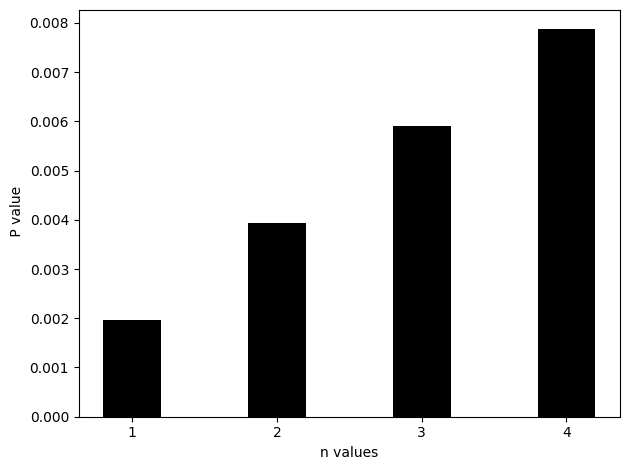

0.00786739748517884


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
L = 0.322

# Set a fixed value for I
I = 10

# Constants
k1 = 0.000268715
k2 = 0.007083518
k3 = 0.760771692
Imax = 35.84931505
I0 = 0.035485714
kd = 5.374494076

# Prepare to store P values for different n
n_values = range(1, 5)  # n from 1 to 4
P_values = []

for n in n_values:
    # Calculate x1
    x1 = np.sqrt((k2 * I + 1)**2 + 8 * L * (k2**2 * k3 * I**2 + k1))
    
    # Calculate F1
    F1 = np.log(L / 2) + np.log((x1 - (k2 * I + 1)) / (x1 + (k2 * I + 1))) + np.log(kd)
    
    # Calculate P
    P = (1 - ((1 - (1 / (1 + np.exp(-F1))))**n))
    
    # Store the average P value for the current n
    P_values.append(np.mean(P))

# Plotting the bar chart
plt.bar(n_values, P_values, color='black', width=0.4)  # Change color to black and adjust width
plt.xlabel('n values')
plt.ylabel(' P value')
plt.title('')
plt.xticks(n_values)  # Ensure we show all n values on the x-axis
plt.grid(False)  # Remove gridlines
plt.tight_layout()  # Adjust layout for compactness
plt.show()
print(P)

n = 1: Normalized L_effective = 1.0
n = 2: Normalized L_effective = 1.8978293632121415
n = 3: Normalized L_effective = 2.703926928658063
n = 4: Normalized L_effective = 3.4276649925292313
n = 1: L_effective = 0.10217063678785798
n = 2: L_effective = 0.19390243455407952
n = 3: L_effective = 0.2762619361288313
n = 4: L_effective = 0.35020671498216005


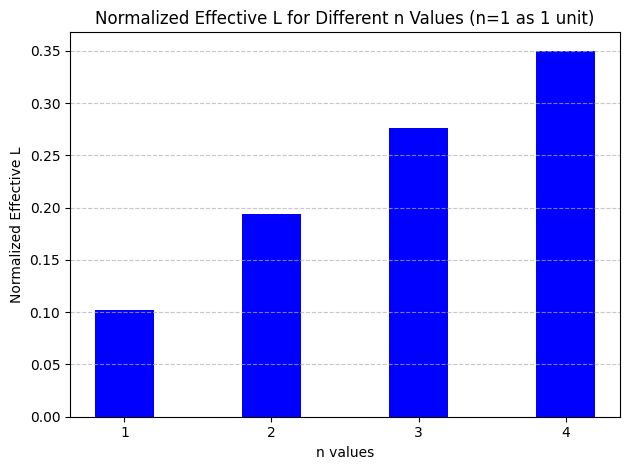

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
L_initial = 2.48 # Initial L
I = 10  # Fixed inducer concentration
k1 = 0.000268715
k2 = 0.007083518
k3 = 0.760771692
kd = 5.374494076

# Prepare to store L values for different n
n_values = range(1, 5)  # n from 1 to 4
L_effective_values = []  # Store effective L values

for n in n_values:
    # Calculate x1
    x1 = np.sqrt((k2 * I + 1)**2 + 8 * L_initial * (k2**2 * k3 * I**2 + k1))

    # Calculate F1
    F1 = np.log(L_initial / 2) + np.log((x1 - (k2 * I + 1)) / (x1 + (k2 * I + 1))) + np.log(kd)

    # Calculate P
    P = 1 - (1 - 1 / (1 + np.exp(-F1)))**n

    # Calculate effective L
    L_effective = P 
    L_effective_values.append(L_effective)

    Y=P*Imax+I0

# Get the effective L for n=1
L_effective_n1 = L_effective_values[0]

# Normalize all L_effective values by dividing by L_effective_n1
L_effective_normalized = [L_effective / L_effective_n1 for L_effective in L_effective_values]

# Print the normalized L values
for n, L_effective in zip(n_values, L_effective_normalized):
    print(f"n = {n}: Normalized L_effective = {L_effective}")# Print the raw (non-normalized) L_effective values

# 正确打印：每个 n 对应一个 L_effective
for n, L_effective in zip(n_values, L_effective_values):
    print(f"n = {n}: L_effective = {L_effective}")


# Plotting the normalized values
plt.bar(n_values, L_effective_values, color='blue', width=0.4)
plt.xlabel('n values')
plt.ylabel('Normalized Effective L')
plt.title('Normalized Effective L for Different n Values (n=1 as 1 unit)')
plt.xticks(n_values)  # Ensure all n values are displayed on the x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for better readability
plt.tight_layout()  # Adjust layout for compactness
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import brentq

# 常量参数
k1 = 4.21691E-22

k2 = 0.039590602


k3 =13.17104327
kx1=0.001007507

kx2=0.001604871
kd = 5.374494076
I = 100
Imax = 35.84931505
I0 = 0.035485714

# 反推 L 和 P 的函数
def solve_L_and_P(Y_target, n):
    def equation(L):
        x1 = np.sqrt((k2*I+kx1+kx2*k2*I+1)*(k2*I+kx1+kx2*k2*I+1)+ 8 * L * (k2*k2*k3*I*I + k1+k1*kx1*kx1+k3*k2*k2*kx2*kx2*I*I))
        F1 = np.log(L / 2) + np.log((x1 - (k2*I+kx1+kx2*k2*I+1)) / (x1 + (k2*I+kx1+kx2*k2*I+1))) + np.log(kd)
        P = 1 - (1 - 1 / (1 + np.exp(-F1)))**n
        Y = P * Imax + I0
        return Y - Y_target

    try:
        L_sol = brentq(equation, 1e-5, 100)
        # 一旦得到 L，重新计算 P
        x1 = np.sqrt((k2*I+kx1+kx2*k2*I+1)*(k2*I+kx1+kx2*k2*I+1)+ 8 * L_sol * (k2*k2*k3*I*I + k1+k1*kx1*kx1+k3*k2*k2*kx2*kx2*I*I))
        F1 = np.log(L_sol / 2) + np.log((x1 - (k2*I+kx1+kx2*k2*I+1)) / (x1 + (k2*I+kx1+kx2*k2*I+1))) + np.log(kd)
        P_sol = 1 - (1 - 1 / (1 + np.exp(-F1)))**n
        return L_sol, P_sol
    except ValueError:
        return np.nan, np.nan  # 无解

# 读取 CSV 文件（确保有列 Y 和 n）
df = pd.read_csv("E:/Desktop/operator.csv")

# 应用反推函数
results = df.apply(lambda row: solve_L_and_P(row['Y'], int(row['n'])), axis=1)

# 拆分结果为两个新列
df['L_estimated'] = [res[0] for res in results]
df['P_estimated'] = [res[1] for res in results]

# 保存结果
df.to_csv("E:/Desktop/estimated_L.csv", index=False)
print("反推完成，已保存为 Yield_with_estimated_L_P.csv")


反推完成，已保存为 Yield_with_estimated_L_P.csv


C:\Users\Chestnut\AppData\Local\Temp\ipykernel_2100\3934537059.py:31: RuntimeWarning: invalid value encountered in log
  F1 = np.log(L/2) + np.log(numerator/denominator) + np.log(kd)


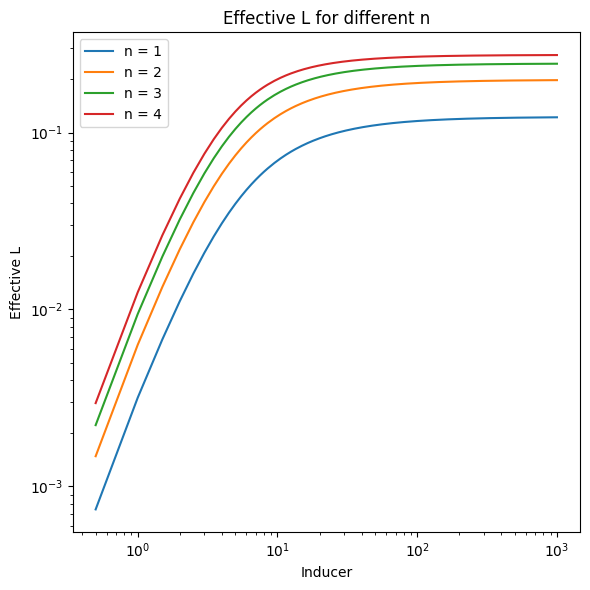

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
L_initial = 0.322 # 初始 L
k1 = 4.21691E-22
k2 = 0.039590602
k3 = 13.17104327
kx1 = 0.001007507
kx2 = 0.001604871
kd = 5.374494076

# Inducer (I) range
I_values = np.linspace(0, 1000, 2000)  # I 从 0.1 到 100，分为 200 个点

# n values
n_values = range(1, 5)  # n 从 1 到 4

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))

for n in n_values:
    L_values = []  # Store effective L for current n
    for I in I_values:
        # Calculate x1
        x1 = np.sqrt((k2 * I + 1)**2 + 8 * L_initial * (k2**2 * k3 * I**2 + k1))
        
        # Calculate F1
        numerator = x1 - (k2*I + kx1 + kx2*k2*I + 1)
        denominator = x1 + (k2*I + kx1 + kx2*k2*I + 1)
        F1 = np.log(L/2) + np.log(numerator/denominator) + np.log(kd)
        

        # Calculate P
        P = (1 - ((1 - (1 / (1 + np.exp(-F1))))**n))
        
        # Calculate effective L
        L_effective = P * L_initial  # 假设有效 L 和 P 成比例
        L_values.append(L_effective)
    
    # Plot the curve for this n
    plt.plot(I_values, L_values, label=f'n = {n}')

# Add labels and legend
ax.set_xscale('log')
ax.set_yscale('log')
plt.xlabel('Inducer')
plt.ylabel('Effective L')
plt.title('Effective L for different n')
plt.legend()


# Show plot
plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19484\3483760928.py:33: RuntimeWarning: divide by zero encountered in log
  F1 = np.log(L/2) + np.log(numerator/denominator) + np.log(kd)


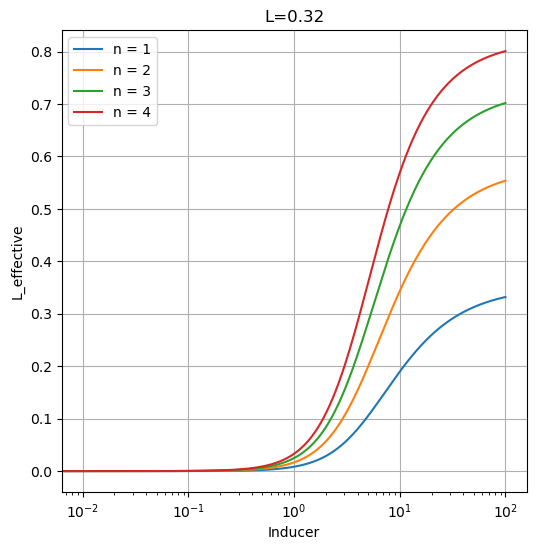

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
L = 0.29

# Set range for I
I = np.arange(0, 100, 0.01)

# Constants
k1 = 4.21691E-22
k2 = 0.039590602
k3 = 13.17104327
kx1 = 0.001007507
kx2 = 0.001604871
kd = 5.374494076
Imax=10.84931505

# Prepare to plot P values for different n
n_values = range(1, 5)  # n from 1 to 4

fig, ax = plt.subplots(figsize=(6, 6))

for n in n_values:
    # Calculate x1
    term1 = (k2*I + kx1 + kx2*k2*I + 1)**2
    term2 = 8 * L * (k2**2*k3*I**2 + k1 + k1*kx1**2 + k3*k2**2*kx2**2*I**2)
    x1 = np.sqrt(term1 + term2)
    
    # Calculate F1
    numerator = x1 - (k2*I + kx1 + kx2*k2*I + 1)
    denominator = x1 + (k2*I + kx1 + kx2*k2*I + 1)
    F1 = np.log(L/2) + np.log(numerator/denominator) + np.log(kd)
    
    # Calculate P
    L_effective = 1 - ((1 - (1 / (1 + np.exp(-F1))))**n)
    
    # Plot P against I for the current n
    plt.plot(I, L_effective, label=f'n = {n}')

# Add labels and title
plt.xlabel('Inducer')
plt.ylabel('L_effective')
plt.title("L=0.32")
ax.set_xscale('log')
plt.legend()
plt.grid()
plt.show()

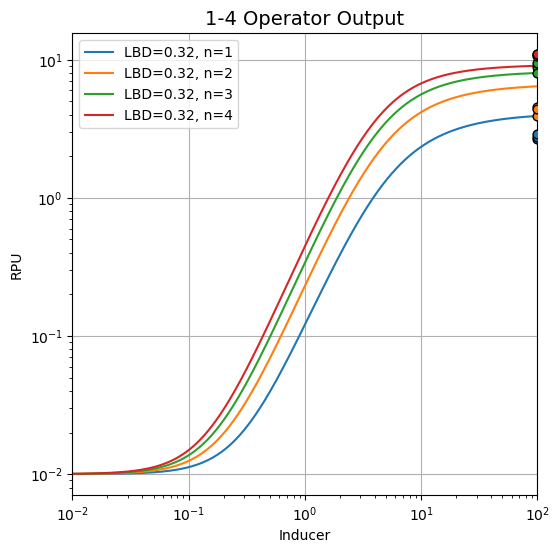

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv(r"E:\Desktop\\1-4operator.csv")
n_values = range(1, 5)
LBD_values = df["LBD"].dropna().unique() # 获取 LBD 列的唯一值

# 参数初始化
I = np.logspace(-3, 2, 1000)  # 避免包含0并确保足够的数据点
k1 = 4.21691E-22
k2 = 0.039590602
k3 = 13.17104327
kx1 = 0.001007507
kx2 = 0.001604871
kd = 5.374494076
Imax=10.84931505

# 创建绘图窗口
fig, ax = plt.subplots(figsize=(6, 6))

# 为每个 n 和 LBD 组合绘制曲线和点
for n in n_values:
    for L in LBD_values:
        # 提取当前LBD和n对应的实验数据
        subset = df[(df["LBD"] == L)]
        x_subset = subset["inducer"]
        column_name = str(n)
        y_subset = subset[column_name]
        
        # 计算理论曲线
        term1 = (k2*I + kx1 + kx2*k2*I + 1)**2
        term2 = 8 * L * (k2**2*k3*I**2 + k1 + k1*kx1**2 + k3*k2**2*kx2**2*I**2)
        x1 = np.sqrt(term1 + term2)
        
        # 计算F1（修正后的公式）
        numerator = x1 - (k2*I + kx1 + kx2*k2*I + 1)
        denominator = x1 + (k2*I + kx1 + kx2*k2*I + 1)
        F1 = np.log(L/2) + np.log(numerator/denominator) + np.log(kd)
        
        # 计算P*
        P= (1 - ((1 - (1 / (1 + np.exp(-F1))))**n))
        P1 = (1 - ((1 - (1 / (1 + np.exp(-F1))))**n)) *Imax+I0
        
        # 绘制理论曲线
        ax.plot(I, P1, label=f'LBD={L:.2f}, n={n}', linewidth=1.5)
        ax.scatter(x_subset, y_subset, s=40, edgecolors='black', zorder=3)
        #ax.plot(I, P, label=f'LBD={L:.2f}, n={n}', linewidth=1.5)
        # 绘制实验数据点
        

# 坐标轴设置
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Inducer', fontsize=10)
ax.set_ylabel('RPU', fontsize=10)

ax.set_xlim(1e-2, 1e2)


# 优化图例显示
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))  # 去重处理
#ax.legend(unique_labels.values(), unique_labels.keys(), 
#         fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.legend(loc='upper left')
# 图表美化
plt.title('1-4 Operator Output', fontsize=14)
plt.grid()
plt.show()

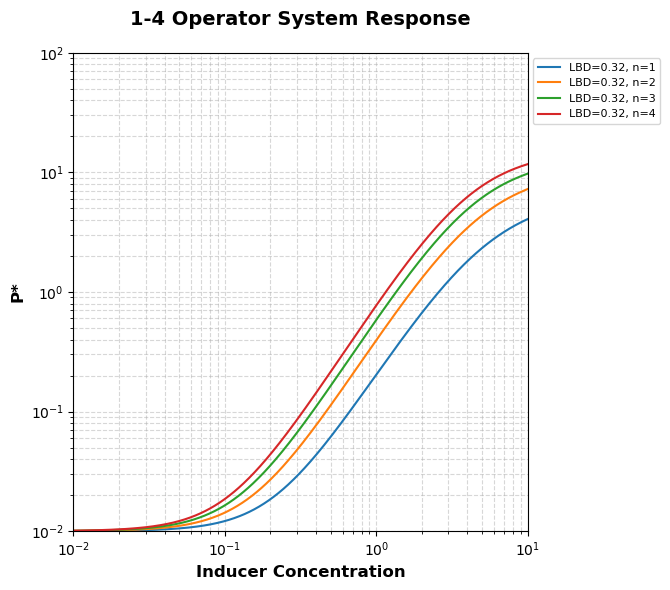

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 读取 CSV 文件（添加na_values处理）
df = pd.read_csv(r"E:\Desktop\1-4operator.csv", na_values=['NA', 'null', 'NaN'])

n_values = range(1, 5)
LBD_values = df["LBD"].dropna().unique()  # 关键修改：排除空值

# 参数初始化（添加I0定义）
I = np.logspace(-3, 1, 1000)
I0 = 0.01  # 添加缺失参数
k1 = 4.21691E-22
k2 = 0.039590602
k3 = 13.17104327
kx1 = 0.001007507
kx2 = 0.001604871
kd = 5.374494076
Imax = 18.84931505

fig, ax = plt.subplots(figsize=(8, 6))

for n in n_values:
    for L in LBD_values:
        # 跳过空值（安全防护）
        if pd.isna(L):
            continue
            
        # 使用安全筛选方式
        subset = df[df["LBD"].apply(lambda x: pd.isna(x) and pd.isna(L) or x == L)]
        
        # 确保有数据才绘制
        if subset.empty:
            continue
            
        x_subset = subset["inducer"]
        column_name = str(n)
        y_subset = subset[column_name]
        
        # 理论计算部分保持不变...
        term1 = (k2*I + kx1 + kx2*k2*I + 1)**2
        term2 = 8 * L * (k2**2*k3*I**2 + k1 + k1*kx1**2 + k3*k2**2*kx2**2*I**2)
        x1 = np.sqrt(term1 + term2)
        
        numerator = x1 - (k2*I + kx1 + kx2*k2*I + 1)
        denominator = x1 + (k2*I + kx1 + kx2*k2*I + 1)
        F1 = np.log(L/2) + np.log(numerator/denominator) + np.log(kd)
        
        P = (1 - ((1 - (1 / (1 + np.exp(-F1))))**n)) * Imax + I0
        
        # 绘制时显示有效LBD值
        ax.plot(I, P, label=f'LBD={L:.2f}, n={n}', linewidth=1.5)
        ax.scatter(x_subset, y_subset, s=40, edgecolors='black', zorder=3)

# 后续设置保持不变...
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Inducer Concentration', fontsize=12, weight='bold')
ax.set_ylabel('P*', fontsize=12, weight='bold')
ax.set_ylim(1e-2, 1e2)
ax.set_xlim(1e-2, 1e1)
ax.grid(True, which='both', linestyle='--', alpha=0.5)

handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(),
         fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

plt.title('1-4 Operator System Response', fontsize=14, weight='bold', pad=20)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()